# CycleSense

## Notebook 01 — Dataset Overview

### Objective

The purpose of this notebook is to perform an initial exploration of the Federal Menstrual Cycle Dataset. We examine the structure of the dataset, summarize the available variables, identify missing values, inspect target variables, and document feature types. No preprocessing or feature engineering is performed in this notebook.

---

### Research Motivation

Reliable prediction of ovulation timing and menstrual cycle characteristics depends on understanding the quality and distribution of the available data. A systematic data audit is therefore the first step before developing machine learning models.

---

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

from src.data_loader import load_data
df = load_data()

Dataset loaded successfully.
Shape: (1665, 80)


## Dataset Preview

Let's inspect the first few records to understand the structure of the dataset.

In [3]:
df.head()

,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,...,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
0,nfp8122,1,0,1,0,29,27.33,17,12,12,...,9,,,2,7,7,1,1,0,21.254724111867
1,nfp8122,2,0,1,0,27,,15,12,13,...,,,,,,,,,,
2,nfp8122,3,0,1,0,29,,15,14,,...,,,,,,,,,,
3,nfp8122,4,0,1,0,27,,15,12,13,...,,,,,,,,,,
4,nfp8122,5,0,1,0,28,,16,12,12,...,,,,,,,,,,


In [4]:
df.sample(5)

,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,...,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
538,nfp8116,10,1,1,0,30,,15,15,10,...,,,,,,,,,,
1467,nfp8305,3,1,1,0,37,,22,15,10,...,,,,,,,,,,
946,nfp8188,16,0,1,0,31,,18,13,,...,,,,,,,,,,
651,nfp8150,5,0,1,0,33,,20,13,15,...,,,,,,,,,,
1246,nfp8268,4,0,1,0,28,,13,15,10,...,,,,,,,,,,


## Dataset Dimensions

In [5]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 1665
Number of Columns : 80


## Dataset Information

Inspect data types and missing values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1665 entries, 0 to 1664
Data columns (total 80 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ClientID                    1665 non-null   object
 1   CycleNumber                 1665 non-null   int64 
 2   Group                       1665 non-null   int64 
 3   CycleWithPeakorNot          1665 non-null   int64 
 4   ReproductiveCategory        1665 non-null   int64 
 5   LengthofCycle               1665 non-null   int64 
 6   MeanCycleLength             1665 non-null   object
 7   EstimatedDayofOvulation     1665 non-null   object
 8   LengthofLutealPhase         1665 non-null   object
 9   FirstDayofHigh              1665 non-null   object
 10  TotalNumberofHighDays       1665 non-null   object
 11  TotalHighPostPeak           1665 non-null   object
 12  TotalNumberofPeakDays       1665 non-null   object
 13  TotalDaysofFertility        1665 non-null   obje

In [7]:
df.dtypes.value_counts()

object    75
int64      5
Name: count, dtype: int64

## Numerical Summary

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CycleNumber,1665.0,8.040841,6.593686,1.0,3.0,7.0,11.0,45.0
Group,1665.0,0.382583,0.486164,0.0,0.0,0.0,1.0,1.0
CycleWithPeakorNot,1665.0,0.912312,0.282925,0.0,1.0,1.0,1.0,1.0
ReproductiveCategory,1665.0,0.055255,0.479706,0.0,0.0,0.0,0.0,9.0
LengthofCycle,1665.0,29.299099,3.887932,18.0,27.0,29.0,31.0,54.0


## Categorical Summary

In [9]:
df.describe(include="object").T

,count,unique,top,freq
ClientID,1665,159,nfp8122,45
MeanCycleLength,1665,105,,1524
EstimatedDayofOvulation,1665,24,14,227
LengthofLutealPhase,1665,30,13,338
FirstDayofHigh,1665,23,,258
...,...,...,...,...
NextpregM,1665,8,,1524
Spousesame,1665,4,,1523
SpousesameM,1665,3,,1523
Timeattemptpreg,1665,2,,1523


## Missing Value Analysis

Understanding missing data is essential before deciding how to preprocess the dataset.

In [10]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing = missing.sort_values(
    by="Percentage",
    ascending=False
)

missing.head(20)

,Missing Values,Percentage
ClientID,0,0.0
CycleNumber,0,0.0
Group,0,0.0
CycleWithPeakorNot,0,0.0
ReproductiveCategory,0,0.0
LengthofCycle,0,0.0
MeanCycleLength,0,0.0
EstimatedDayofOvulation,0,0.0
LengthofLutealPhase,0,0.0
FirstDayofHigh,0,0.0


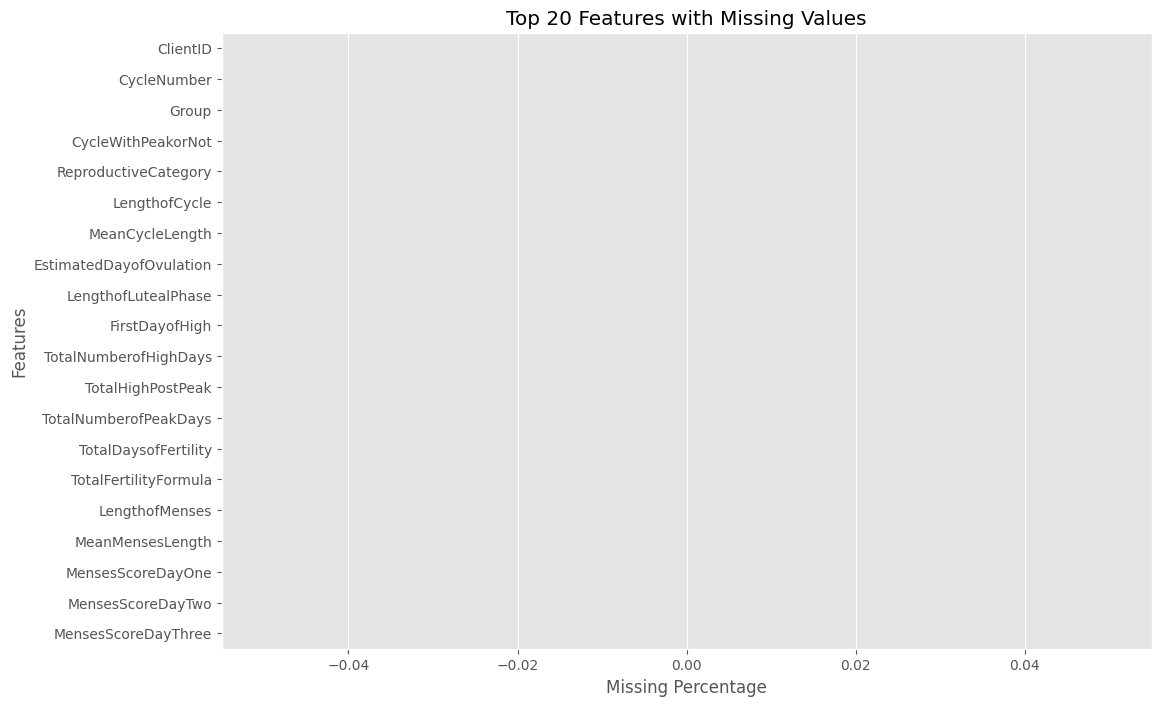

In [11]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=missing.head(20),
    x="Percentage",
    y=missing.head(20).index
)

plt.title("Top 20 Features with Missing Values")

plt.xlabel("Missing Percentage")

plt.ylabel("Features")

plt.show()

## Duplicate Records

In [12]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 12


## Feature Types

In [14]:
numeric_features = df.select_dtypes(include=np.number).columns

categorical_features = df.select_dtypes(exclude=np.number).columns

print(f"Numerical Features    : {len(numeric_features)}")

print(f"Categorical Features  : {len(categorical_features)}")

Numerical Features    : 5
Categorical Features  : 75


In [15]:
numeric_features

Index(['CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory',
       'LengthofCycle'],
      dtype='object')

In [16]:
categorical_features

Index(['ClientID', 'MeanCycleLength', 'EstimatedDayofOvulation',
       'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays',
       'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility',
       'TotalFertilityFormula', 'LengthofMenses', 'MeanMensesLength',
       'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree',
       'MensesScoreDayFour', 'MensesScoreDayFive', 'MensesScoreDaySix',
       'MensesScoreDaySeven', 'MensesScoreDayEight', 'MensesScoreDayNine',
       'MensesScoreDayTen', 'MensesScoreDay11', 'MensesScoreDay12',
       'MensesScoreDay13', 'MensesScoreDay14', 'MensesScoreDay15',
       'TotalMensesScore', 'MeanBleedingIntensity',
       'NumberofDaysofIntercourse', 'IntercourseInFertileWindow',
       'UnusualBleeding', 'PhasesBleeding', 'IntercourseDuringUnusBleed',
       'Age', 'AgeM', 'Maristatus', 'MaristatusM', 'Yearsmarried', 'Wedding',
       'Religion', 'ReligionM', 'Ethnicity', 'EthnicityM', 'Schoolyears',
       'Schoolyea

# Target Variables

Our project focuses on three prediction tasks:

1. Estimated Day of Ovulation (Regression)

2. Length of Cycle (Regression)

3. Cycle With Peak or Not (Classification)

In [17]:
targets = [
    "EstimatedDayofOvulation",
    "LengthofCycle",
    "CycleWithPeakorNot"
]

df[targets].head()

,EstimatedDayofOvulation,LengthofCycle,CycleWithPeakorNot
0,17,29,1
1,15,27,1
2,15,29,1
3,15,27,1
4,16,28,1


In [18]:
df[targets].describe()

,LengthofCycle,CycleWithPeakorNot
count,1665.000000,1665.000000
mean,29.299099,0.912312
std,3.887932,0.282925
min,18.000000,0.000000
25%,27.000000,1.000000
50%,29.000000,1.000000
75%,31.000000,1.000000
max,54.000000,1.000000


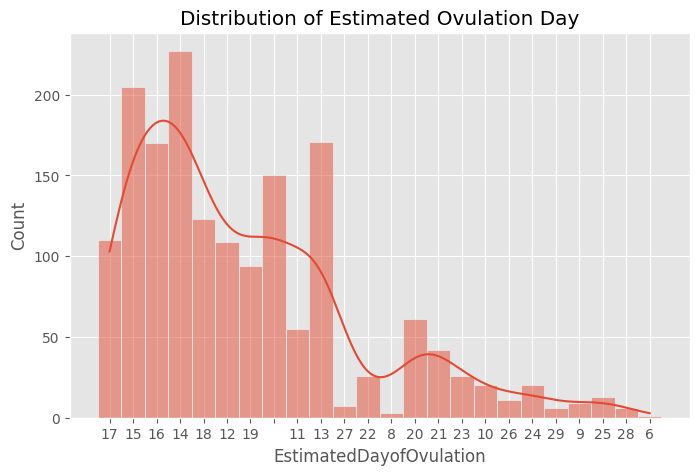

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["EstimatedDayofOvulation"],
    bins=20,
    kde=True
)

plt.title("Distribution of Estimated Ovulation Day")

plt.show()

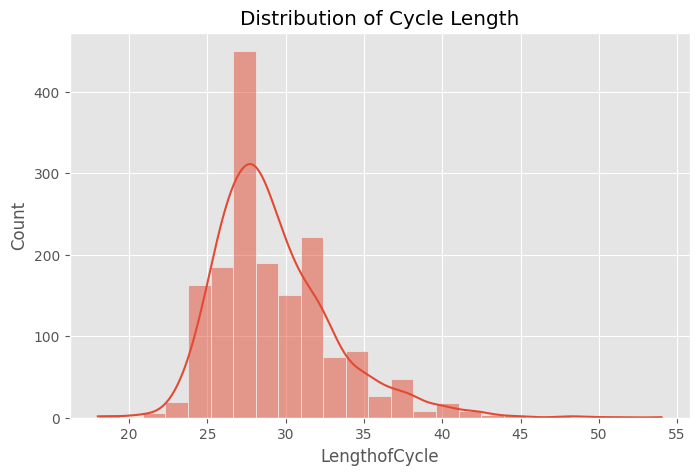

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["LengthofCycle"],
    bins=25,
    kde=True
)

plt.title("Distribution of Cycle Length")

plt.show()

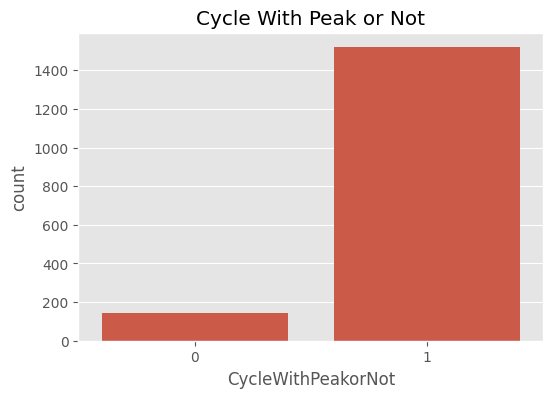

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["CycleWithPeakorNot"]
)

plt.title("Cycle With Peak or Not")

plt.show()

## Dataset Overview Table

In [22]:
overview = pd.DataFrame({

    "Column": df.columns,

    "Data Type": df.dtypes.astype(str),

    "Missing Values": df.isnull().sum(),

    "Unique Values": df.nunique()

})

overview

,Column,Data Type,Missing Values,Unique Values
ClientID,ClientID,object,0,159
CycleNumber,CycleNumber,int64,0,45
Group,Group,int64,0,2
CycleWithPeakorNot,CycleWithPeakorNot,int64,0,2
ReproductiveCategory,ReproductiveCategory,int64,0,4
...,...,...,...,...
NextpregM,NextpregM,object,0,8
Spousesame,Spousesame,object,0,4
SpousesameM,SpousesameM,object,0,3
Timeattemptpreg,Timeattemptpreg,object,0,2


In [23]:
overview.to_csv(
    "../reports/data_overview.csv",
    index=False
)

# Observations

After the initial inspection, we have identified:

- Dataset dimensions and feature types.
- Missing values across multiple variables.
- Three target variables for regression and classification tasks.
- Numerical and categorical feature distributions.

